# 06 — Tuning

This notebook performs hyperparameter tuning for Logistic Regression, Gradient Boosting, and XGBoost using GroupKFold cross-validation. Tuned models are then calibrated using isotonic regression and evaluated on the test set.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from src.modeling import tune_models
from src.calibration import manual_calibration, predict_calibrated, metrics_from_probs
from src.config import SEED, param_grids
from src.visualization import plot_calibration_curves
from sklearn.pipeline import make_pipeline

In [2]:
# Load preprocessed data
X_tr_prep = pd.read_csv("../data/processed/X_tr_prep.csv").values
X_te_prep = pd.read_csv("../data/processed/X_te_prep.csv").values

y_tr = pd.read_csv("../data/processed/y_tr.csv")["target"].values
y_te = pd.read_csv("../data/processed/y_te.csv")["target"].values

groups = pd.read_csv("../data/processed/train_ids.csv")["id"].values

# Load preprocessor
preprocessor = joblib.load("../models/preprocessor.pkl")

In [3]:
# Tuning 
best_tuned_models = tune_models(X_tr_prep, y_tr, groups, seed=SEED)

# Save tuned models
for name, model in best_tuned_models.items():
    filename = f"../models/{name.replace(' ', '_').lower()}_tuned.pkl"
    joblib.dump(model, filename)

df_tuned = pd.DataFrame(best_tuned_models).T
df_tuned.to_csv("../reports/tables/tuning_metrics.csv")

# Save tuned pipelines
for name, model in best_tuned_models.items():
    pipeline = make_pipeline(preprocessor, model)
    filename = f"../models/{name.replace(' ', '_').lower()}_tuned_pipeline.pkl"
    joblib.dump(pipeline, filename)

Tuning Logistic Regression...
Best params for Logistic Regression: {'C': 0.01, 'l1_ratio': 0.5, 'max_iter': 1000, 'solver': 'saga'}
Tuning Gradient Boosting...
Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Tuning XGBoost...
Best params for XGBoost: {'colsample_bytree': 1.0, 'eval_metric': 'aucpr', 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 500, 'n_jobs': -1, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'hist', 'use_label_encoder': False, 'verbosity': 0}


In [4]:
# Calibration
calibrated_tuned_models = {}

for name, model in best_tuned_models.items():
    print(f"Calibrating {name}...")
    _, calibrator = manual_calibration(model, X_tr_prep, y_tr, groups)
    calibrated_tuned_models[name] = calibrator

for name, calibrator in calibrated_tuned_models.items():
    filename = f"../models/{name.replace(' ', '_').lower()}_tuned_calibrator.pkl"
    joblib.dump(calibrator, filename)

calibrated_tuned_models

Calibrating Logistic Regression...
Calibrating Gradient Boosting...
Calibrating XGBoost...


{'Logistic Regression': IsotonicRegression(out_of_bounds='clip'),
 'Gradient Boosting': IsotonicRegression(out_of_bounds='clip'),
 'XGBoost': IsotonicRegression(out_of_bounds='clip')}

In [5]:
# Compute calibrated metrics
calibrated_metrics = {}

for name, model in best_tuned_models.items():
    cal = calibrated_tuned_models[name]
    y_pred = predict_calibrated(model, cal, X_te_prep)
    calibrated_metrics[name] = metrics_from_probs(y_te, y_pred)

df_cal = pd.DataFrame(calibrated_metrics).T
df_cal.to_csv("../reports/tables/tunned_calibration_metrics.csv")
df_cal

,ROC-AUC,PR-AUC,Brier,ECE,TP,TN,FP,FN,Precision,Sensitivity
Logistic Regression,0.715614,0.754358,0.214154,0.065473,454.0,135.0,220.0,70.0,0.673591,0.866412
Gradient Boosting,0.670979,0.716547,0.222031,0.046943,410.0,162.0,193.0,114.0,0.679934,0.782443
XGBoost,0.679690,0.718613,0.221127,0.058728,404.0,173.0,182.0,120.0,0.689420,0.770992


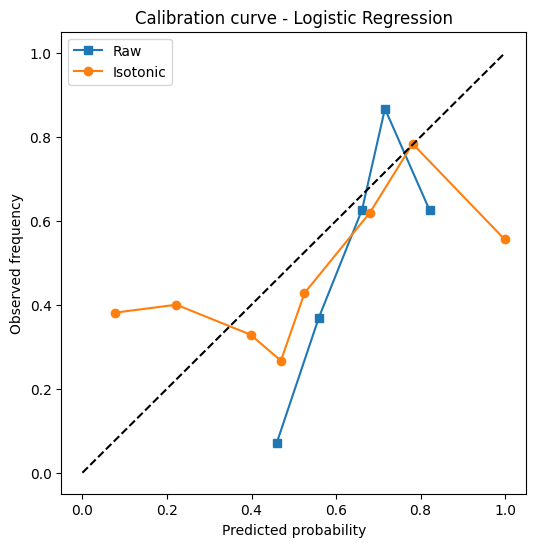

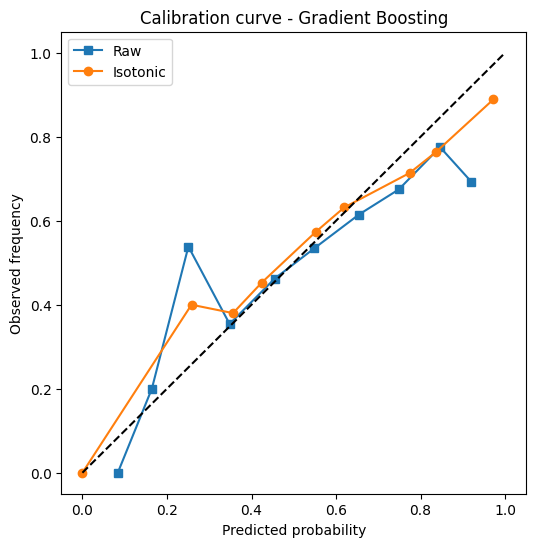

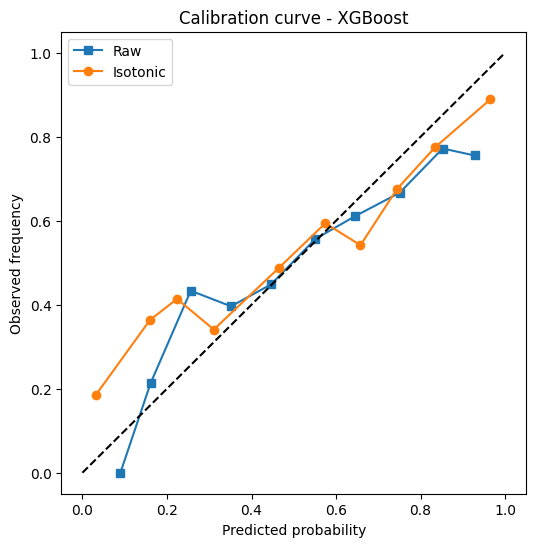

In [9]:
# Calibration curves
for name, model in best_tuned_models.items():
    figs = plot_calibration_curves(
        models={name: model},
        calibrated_models={name: calibrated_tuned_models[name]},
        X=X_te_prep,
        y=y_te,
    )
    figs[name].savefig(f"../reports/figures/tuned_calibration_curve_{name.replace(' ', '_').lower()}.png")